        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Número de imágenes: 3662

Distribución de clases:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


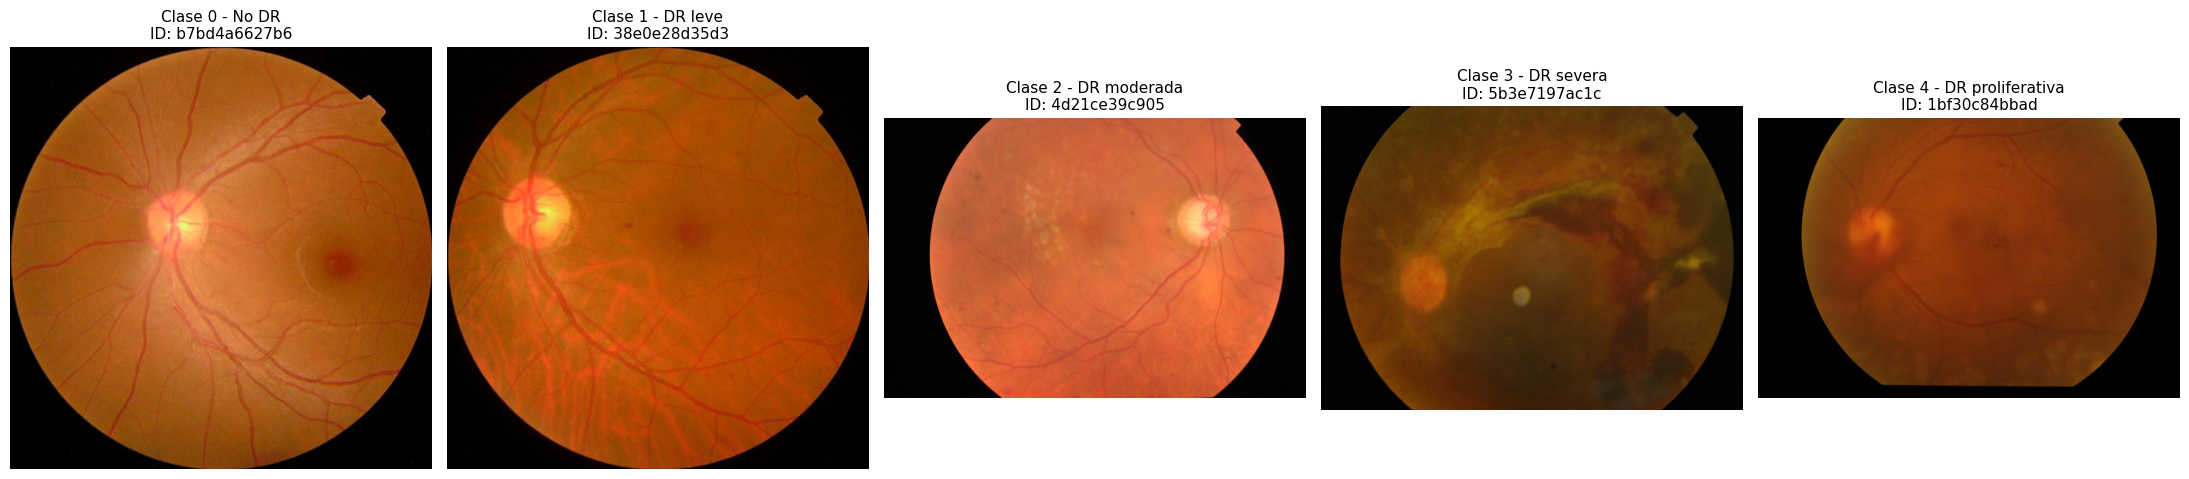

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Ruta base del dataset
BASE_DIR = "./aptos2019-blindness-detection"

# Rutas
csv_path = os.path.join(BASE_DIR, "train.csv")
image_dir = os.path.join(BASE_DIR, "train_images")

# Cargar etiquetas
df = pd.read_csv(csv_path)

# Verificar los datos
print(df.head())
print(f"\nNúmero de imágenes: {len(df)}")
print("\nDistribución de clases:")
print(df["diagnosis"].value_counts().sort_index())


import random

clases = [0, 1, 2, 3, 4]

imagenes = []

for clase in clases:
    datos_clase = df[df["diagnosis"] == clase]
    
    # Seleccionar una imagen aleatoria
    fila = datos_clase.sample(1).iloc[0]
    
    nombre = fila["id_code"]
    ruta = os.path.join(image_dir, nombre + ".png")
    
    imagenes.append((clase, ruta, nombre))


nombres_clases = {
    0: "Clase 0 - No DR",
    1: "Clase 1 - DR leve",
    2: "Clase 2 - DR moderada",
    3: "Clase 3 - DR severa",
    4: "Clase 4 - DR proliferativa"
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (clase, ruta, nombre) in zip(axes, imagenes):
    
    imagen = Image.open(ruta)
    
    ax.imshow(imagen)
    ax.set_title(
        f"{nombres_clases[clase]}\nID: {nombre}",
        fontsize=11
    )
    ax.axis("off")

plt.tight_layout()
plt.show()
